In [538]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d
from scipy.integrate import simpson

In [539]:
df = pd.read_csv("Nb3d_W201_E.csv")
#fwhm, area, peak, position
# Use first two columns: Binding Energy and Intensity
x_original = df.iloc[:, 0].to_numpy(dtype=float)
y_original = df.iloc[:, 1].to_numpy(dtype=float)

GENERATE BACKGROUND

In [540]:
def auto_shirley_window(
    x,
    y,
    smooth_fraction=0.04,
    threshold_fraction=0.015,
    pad_fraction=0.06,
):
    """
    Propose a Shirley window around the detected peak envelope.

    The returned endpoints should be inspected manually before
    quantitative analysis.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    n = len(y_sorted)

    window = max(5, int(round(n * smooth_fraction)))

    if window % 2 == 0:
        window += 1

    largest_odd_window = n if n % 2 == 1 else n - 1
    window = min(window, largest_odd_window)

    half_window = window // 2
    kernel = np.ones(window, dtype=float) / window

    # Avoid zero-padding artifacts at the two data boundaries.
    y_padded = np.pad(
        y_sorted,
        pad_width=half_window,
        mode="edge"
    )

    y_smooth = np.convolve(
        y_padded,
        kernel,
        mode="valid"
    )

    edge_points = max(3, int(round(n * 0.08)))

    y_lowBE = np.median(y_smooth[:edge_points])
    y_highBE = np.median(y_smooth[-edge_points:])

    rough_baseline = np.linspace(
        y_lowBE,
        y_highBE,
        n
    )

    residual = y_smooth - rough_baseline
    positive_residual = np.maximum(residual, 0.0)

    residual_max = np.max(positive_residual)

    if residual_max <= 0:
        return float(x_sorted[0]), float(x_sorted[-1])

    active = np.flatnonzero(
        positive_residual
        > threshold_fraction * residual_max
    )

    if len(active) == 0:
        peak_index = int(np.argmax(positive_residual))
        active = np.array([peak_index])

    pad_points = max(2, int(round(n * pad_fraction)))

    left = max(0, active[0] - pad_points)
    right = min(n - 1, active[-1] + pad_points)

    return float(x_sorted[left]), float(x_sorted[right])

In [541]:
def shirley_background(
    x,
    y,
    fit_min=None,
    fit_max=None,
    endpoint_points=5,
    max_iter=500,
    rtol=1e-8,
    atol=1e-6,
):
    """
    Calculate a classic iterative Shirley background over a limited
    near-peak XPS energy range.

    Parameters
    ----------
    x : array-like
        Binding energy values.
    y : array-like
        Intensity values, preferably corrected for analyzer transmission.
    fit_min, fit_max : float, optional
        Binding-energy limits of the Shirley region.
    endpoint_points : int
        Number of points used to estimate each endpoint intensity.
    max_iter : int
        Maximum number of Shirley iterations.
    rtol, atol : float
        Relative and absolute convergence tolerances.

    Returns
    -------
    background : ndarray
        Shirley background in the original data order. Values outside
        the selected range are NaN.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.ndim != 1 or y.ndim != 1:
        raise ValueError("x and y must be one-dimensional arrays.")

    if len(x) != len(y):
        raise ValueError("x and y must have the same length.")

    if len(x) < 3:
        raise ValueError("At least three data points are required.")

    if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
        raise ValueError("x and y must contain only finite values.")

    # Sort from low binding energy to high binding energy.
    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    # Duplicate energy values make integration ambiguous.
    if np.any(np.diff(x_sorted) <= 0):
        raise ValueError("Binding-energy values must be unique.")

    if fit_min is None:
        fit_min = float(x_sorted[0])

    if fit_max is None:
        fit_max = float(x_sorted[-1])

    fit_min, fit_max = sorted((float(fit_min), float(fit_max)))

    fit_mask = (x_sorted >= fit_min) & (x_sorted <= fit_max)

    if np.count_nonzero(fit_mask) < 3:
        raise ValueError(
            "The Shirley fit range must contain at least three points."
        )

    x_fit = x_sorted[fit_mask]
    y_fit = y_sorted[fit_mask]

    n_endpoint = min(
        int(endpoint_points),
        max(1, len(y_fit) // 4)
    )

    # Median endpoint levels reduce sensitivity to individual noisy points.
    y_lowBE = float(np.median(y_fit[:n_endpoint]))
    y_highBE = float(np.median(y_fit[-n_endpoint:]))

    # Initial approximation.
    bg = np.full_like(y_fit, y_lowBE, dtype=float)

    converged = False

    for iteration in range(1, max_iter + 1):
        bg_old = bg.copy()

        # Do not clip negative values; retain the iterative Shirley equation.
        net = y_fit - bg_old

        # Cumulative trapezoidal integral from low BE to high BE.
        dx = np.diff(x_fit)
        trapezoids = 0.5 * (net[:-1] + net[1:]) * dx

        cumulative_area = np.concatenate(
            ([0.0], np.cumsum(trapezoids))
        )

        total_area = cumulative_area[-1]

        if (
            not np.isfinite(total_area)
            or abs(total_area) < np.finfo(float).eps
        ):
            raise RuntimeError(
                "The net Shirley area is zero or non-finite. "
                "Check the selected endpoints."
            )

        bg = (
            y_lowBE
            + (y_highBE - y_lowBE)
            * cumulative_area
            / total_area
        )

        if np.allclose(bg, bg_old, rtol=rtol, atol=atol):
            converged = True
            print(f"Converged after {iteration} iterations")
            break

    if not converged:
        raise RuntimeError(
            f"Shirley background did not converge after "
            f"{max_iter} iterations."
        )

    bg_sorted = np.full(y_sorted.shape, np.nan, dtype=float)
    bg_sorted[fit_mask] = bg

    background = np.empty_like(bg_sorted)
    background[order] = bg_sorted

    return background

In [542]:
# Only divide by transmission if Count/s has not already been corrected.
y_for_analysis = y_original
# y_for_analysis = count_per_second / transmission

SHIRLEY_MIN_BE, SHIRLEY_MAX_BE = auto_shirley_window(
    x_original,
    y_for_analysis
)

print(
    f"Proposed Shirley window: "
    f"{SHIRLEY_MIN_BE:.2f} to {SHIRLEY_MAX_BE:.2f} eV"
)

shirley = shirley_background(
    x_original,
    y_for_analysis,
    fit_min=SHIRLEY_MIN_BE,
    fit_max=SHIRLEY_MAX_BE,
    endpoint_points=5
)

corrected = y_for_analysis - shirley

Proposed Shirley window: 200.20 to 213.40 eV
Converged after 7 iterations


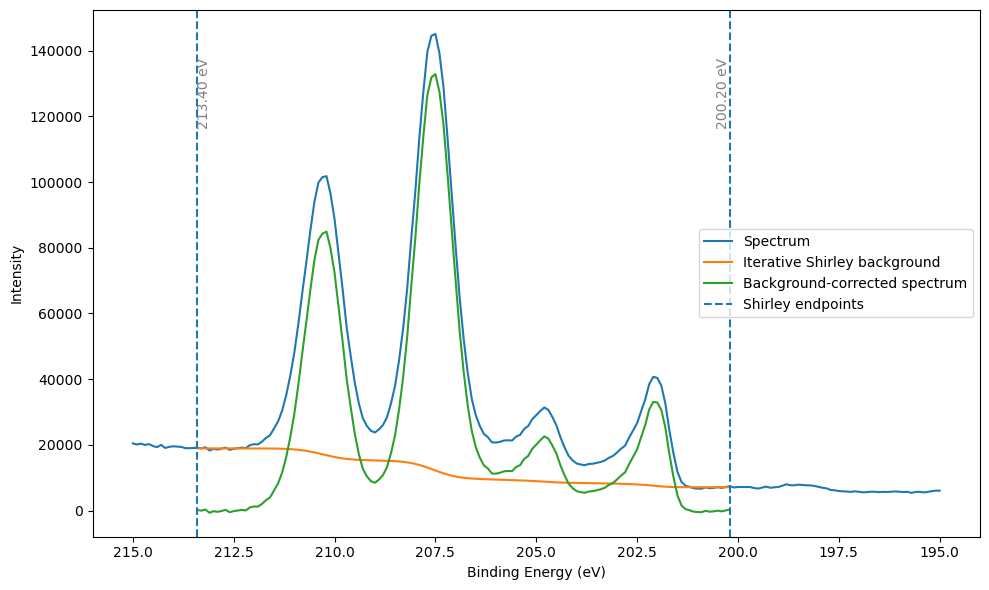

In [543]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    x_original,
    y_for_analysis,
    label="Spectrum"
)

plt.plot(
    x_original,
    shirley,
    label="Iterative Shirley background"
)

plt.plot(
    x_original,
    corrected,
    label="Background-corrected spectrum"
)

plt.axvline(
    SHIRLEY_MIN_BE,
    linestyle="--",
    label="Shirley endpoints"
)

plt.axvline(
    SHIRLEY_MAX_BE,
    linestyle="--"
)

y_top = np.max(y_original)

plt.text(SHIRLEY_MIN_BE, y_top * 0.95, f"{SHIRLEY_MIN_BE:.2f} eV",
         rotation=90, va="top", ha="right", fontsize=10, color="gray")

plt.text(SHIRLEY_MAX_BE, y_top * 0.95, f"{SHIRLEY_MAX_BE:.2f} eV",
         rotation=90, va="top", ha="left", fontsize=10, color="gray")

plt.xlabel("Binding Energy (eV)")
plt.ylabel("Intensity")
plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()

FITTING

In [544]:
df = pd.read_csv("Nb3d_shirley_corrected.csv")

x = df["BindingEnergy"].to_numpy(dtype=float)
y = df["CorrectedIntensity"].to_numpy(dtype=float)

In [545]:
# Only fit Nb 3d region
mask = (x >= SHIRLEY_MIN_BE) & (x <= SHIRLEY_MAX_BE)
x = x[mask]
y = y[mask]

# Sort increasing
order = np.argsort(x)
x = x[order]
y = y[order]

# Remove negative values after background subtraction
y = y - np.min(y)

In [546]:
def pseudo_voigt(x, height, center, fwhm, eta):
    sigma = fwhm / 2.35482

    gaussian = np.exp(-((x - center) ** 2) / (2 * sigma ** 2))
    lorentzian = 1 / (1 + 4 * ((x - center) / fwhm) ** 2)

    return height * ((1 - eta) * gaussian + eta * lorentzian)


In [547]:
def estimate_peak_fwhm(x, y, center_guess):
    """Estimate the FWHM of a local peak from the data near a guessed center."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 3:
        return np.nan

    peak_idx = int(np.argmin(np.abs(x - center_guess)))
    peak_height = float(y[peak_idx])

    if not np.isfinite(peak_height) or peak_height <= 0:
        return np.nan

    half_height = peak_height / 2.0

    left_mask = (x <= x[peak_idx]) & (y <= half_height)
    right_mask = (x >= x[peak_idx]) & (y <= half_height)

    left_candidates = np.flatnonzero(left_mask)
    right_candidates = np.flatnonzero(right_mask)

    if left_candidates.size == 0 or right_candidates.size == 0:
        return np.nan

    left_idx = left_candidates[-1]
    right_idx = right_candidates[0]

    if left_idx == right_idx:
        return np.nan

    if left_idx + 1 < len(x):
        left_x = np.interp(
            half_height,
            [y[left_idx], y[left_idx + 1]],
            [x[left_idx], x[left_idx + 1]],
        )
    else:
        left_x = x[left_idx]

    if right_idx - 1 >= 0:
        right_x = np.interp(
            half_height,
            [y[right_idx - 1], y[right_idx]],
            [x[right_idx - 1], x[right_idx]],
        )
    else:
        right_x = x[right_idx]

    return float(abs(right_x - left_x))


In [548]:
SPLIT = 2.72
RATIO = 2/3   # 3d3/2 relative to 3d5/2

def oxide_doublet(x, height, center_5_2, fwhm, eta):
    p_5_2 = pseudo_voigt(x, height, center_5_2, fwhm, eta)
    p_3_2 = pseudo_voigt(x, height * RATIO, center_5_2 + SPLIT, fwhm, eta)
    return p_5_2 + p_3_2

# Keep this available if you want to try the older asymmetric metal peak shape later.
def LA_peak(x, height, center, fwhm, alpha=1.2, beta=5, m=12):
    gamma = fwhm / 2
    L = 1 / (1 + ((x - center) / gamma)**2)

    y = np.zeros_like(x, dtype=float)

    low_be = x <= center
    high_be = x > center

    y[low_be] = L[low_be] ** beta
    y[high_be] = L[high_be] ** alpha

    if m > 0:
        sigma_points = m / 10
        y = gaussian_filter1d(y, sigma=sigma_points)

    return height * y / np.max(y)


def metal_doublet(x, height, center_5_2, fwhm, eta=0.25):
    """Metallic Nb 3d doublet using a pseudo-Voigt line shape."""
    p_5_2 = pseudo_voigt(x, height, center_5_2, fwhm, eta)
    p_3_2 = pseudo_voigt(x, height * RATIO, center_5_2 + SPLIT, fwhm, eta)
    return p_5_2 + p_3_2


In [549]:
def total_model(x,
                h_m, be_m, fwhm_m,
                h_nbo, be_nbo, eta_nbo,
                h_nbo2, be_nbo2, eta_nbo2,
                h_nb2o5, be_nb2o5, fwhm_oxide, eta_nb2o5):

    return (
        metal_doublet(x, h_m, be_m, fwhm_m) +
        oxide_doublet(x, h_nbo, be_nbo, fwhm_oxide, eta_nbo) +
        oxide_doublet(x, h_nbo2, be_nbo2, fwhm_oxide, eta_nbo2) +
        oxide_doublet(x, h_nb2o5, be_nb2o5, fwhm_oxide, eta_nb2o5)
    )

In [ ]:
metal_fwhm_guess = estimate_peak_fwhm(x, y, 202.3)
if not np.isfinite(metal_fwhm_guess) or metal_fwhm_guess <= 0:
    metal_fwhm_guess = 0.9

oxide_fwhm_guess = 1.0


def estimate_center_from_data(x, y, lo, hi):
    mask = (x >= lo) & (x <= hi)
    if np.count_nonzero(mask) == 0:
        return np.nan
    idx = np.argmax(y[mask])
    return float(x[mask][idx])

nbo_center_guess = estimate_center_from_data(x, y, 202.7, 204.7)
nbo2_center_guess = estimate_center_from_data(x, y, 205.2, 207.2)
nb2o5_center_guess = estimate_center_from_data(x, y, 206.8, 207.8)

if not np.isfinite(nbo_center_guess):
    nbo_center_guess = 203.3
if not np.isfinite(nbo2_center_guess):
    nbo2_center_guess = 205.8
if not np.isfinite(nb2o5_center_guess):
    nb2o5_center_guess = 207.1

p0 = [
    1000, 202.3, metal_fwhm_guess,      # Nb metal: height, BE, FWHM
    800, nbo_center_guess, 0.25,        # NbO: height, BE, eta
    2000, nbo2_center_guess, 0.25,      # NbO2: height, BE, eta
    5000, nb2o5_center_guess, oxide_fwhm_guess, 0.25  # Nb2O5: height, BE, shared oxide FWHM, eta
]

print(f"Estimated metal FWHM from data: {metal_fwhm_guess:.3f}")
print(f"Initial oxide FWHM guess: {oxide_fwhm_guess:.3f}")
print(f"Initial NbO center guess: {nbo_center_guess:.3f}")
print(f"Initial NbO2 center guess: {nbo2_center_guess:.3f}")
print(f"Initial Nb2O5 center guess: {nb2o5_center_guess:.3f}")


Estimated metal FWHM from data: 1.164


In [ ]:
lower = [
    0, 201.9, 0.05,
    0, 202.7, 0.0,
    0, 205.2, 0.0,
    0, 206.8, 0.2, 0.0
]


In [ ]:
upper = [
    np.inf, 202.6, 3.0,
    np.inf, 204.7, 1.0,
    np.inf, 207.2, 1.0,
    np.inf, 207.8, 3.0, 1.0
]


In [553]:
popt, pcov = curve_fit(
    total_model,
    x,
    y,
    p0=p0,
    bounds=(lower, upper),
    maxfev=20000000
)

In [554]:
print("popt values:")
for i, value in enumerate(popt):
    print(f"popt[{i}] = {value}")

popt values:
popt[0] = 29311.549355208208
popt[1] = 202.04472800798956
popt[2] = 0.6908181238965001
popt[3] = 10836.279268855851
popt[4] = 202.76337686293337
popt[5] = 0.9999999999999999
popt[6] = 5474.015525288982
popt[7] = 206.01496338397408
popt[8] = 0.9999999999999999
popt[9] = 129712.19078767888
popt[10] = 207.55011703539543
popt[11] = 1.1202751981789576
popt[12] = 0.09290814838026133


In [555]:
nb_m = metal_doublet(x, popt[0], popt[1], popt[2])

oxide_fwhm = popt[11]

nbo = oxide_doublet(x, popt[3], popt[4], oxide_fwhm, popt[5])
nbo2 = oxide_doublet(x, popt[6], popt[7], oxide_fwhm, popt[8])
nb2o5 = oxide_doublet(x, popt[9], popt[10], oxide_fwhm, popt[12])


In [ ]:
metal_center_5_2 = popt[1]
metal_fwhm = popt[2]
metal_center_3_2 = metal_center_5_2 + 2.72

nbo_center_5_2 = popt[4]
nbo_center_3_2 = nbo_center_5_2 + 2.72
nbo2_center_5_2 = popt[7]
nbo2_center_3_2 = nbo2_center_5_2 + 2.72
nb2o5_center_5_2 = popt[10]
nb2o5_center_3_2 = nb2o5_center_5_2 + 2.72

print("\nFIT RESULTS\n")

print(f"Nb metal 3d5/2: {metal_center_5_2:.3f} eV, FWHM = {metal_fwhm:.3f}")
print(f"Nb metal 3d3/2: {metal_center_3_2:.3f} eV")
print(f"NbO      3d5/2: {nbo_center_5_2:.3f} eV, FWHM = {oxide_fwhm:.3f}")
print(f"NbO      3d3/2: {nbo_center_3_2:.3f} eV")
print(f"NbO2     3d5/2: {nbo2_center_5_2:.3f} eV, FWHM = {oxide_fwhm:.3f}")
print(f"NbO2     3d3/2: {nbo2_center_3_2:.3f} eV")
print(f"Nb2O5    3d5/2: {nb2o5_center_5_2:.3f} eV, FWHM = {oxide_fwhm:.3f}")
print(f"Nb2O5    3d3/2: {nb2o5_center_3_2:.3f} eV")

print("\nFixed doublet separation = 2.72 eV")
print("Fixed area ratio 3d5/2 : 3d3/2 = 3 : 2")



FIT RESULTS

Nb metal 3d5/2: 202.045 eV, FWHM = 0.691
NbO      3d5/2: 202.763 eV, FWHM = 1.120
NbO2     3d5/2: 206.015 eV, FWHM = 1.120
Nb2O5    3d5/2: 207.550 eV, FWHM = 1.120

Fixed doublet separation = 2.72 eV
Fixed area ratio 3d5/2 : 3d3/2 = 3 : 2


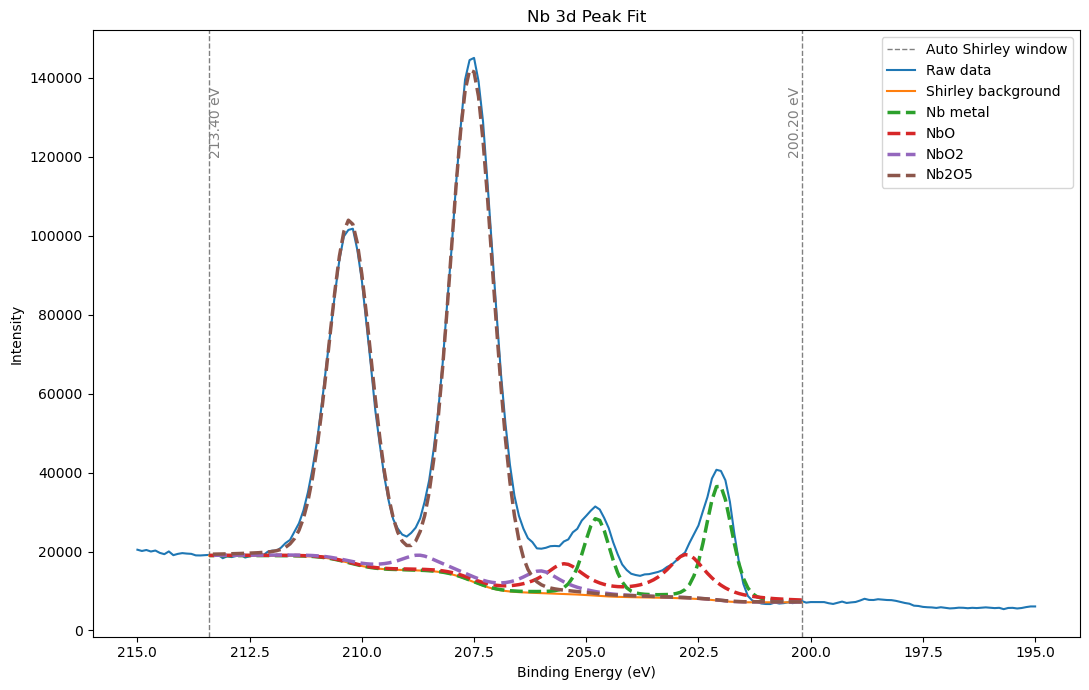

In [557]:
valid = np.isfinite(shirley)
order_bg = np.argsort(x_original[valid])

shirley_fit = np.interp(
    x,
    x_original[valid][order_bg],
    shirley[valid][order_bg]
)

plt.figure(figsize=(11, 7))

plt.axvline(SHIRLEY_MIN_BE, color="gray", linestyle="--", linewidth=1, label="Auto Shirley window")
plt.axvline(SHIRLEY_MAX_BE, color="gray", linestyle="--", linewidth=1)

plt.plot(x_original, y_original, label="Raw data", zorder=2)
plt.plot(x_original, shirley, label="Shirley background", zorder=3)

nb_m_fit = nb_m + shirley_fit
nbo_fit = nbo + shirley_fit
nbo2_fit = nbo2 + shirley_fit
nb2o5_fit = nb2o5 + shirley_fit

plt.plot(x, nb_m_fit, "--", linewidth=2.5, label="Nb metal", zorder=4)
plt.plot(x, nbo_fit, "--", linewidth=2.5, label="NbO", zorder=6)
plt.plot(x, nbo2_fit, "--", linewidth=2.5, label="NbO2", zorder=6)
plt.plot(x, nb2o5_fit, "--", linewidth=2.5, label="Nb2O5", zorder=6)



y_top = np.max(y_original)

plt.text(SHIRLEY_MIN_BE, y_top * 0.95, f"{SHIRLEY_MIN_BE:.2f} eV",
         rotation=90, va="top", ha="right", fontsize=10, color="gray")

plt.text(SHIRLEY_MAX_BE, y_top * 0.95, f"{SHIRLEY_MAX_BE:.2f} eV",
         rotation=90, va="top", ha="left", fontsize=10, color="gray")

plt.xlabel("Binding Energy (eV)")
plt.ylabel("Intensity")
plt.title("Nb 3d Peak Fit")
plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()

In [558]:
x1 = SHIRLEY_MIN_BE
x2 = SHIRLEY_MAX_BE

mask = (x >= x1) & (x <= x2)

# Use a denser grid for a more accurate numerical integration of the smooth fitted curves.
x_dense = np.linspace(x1, x2, 5000)

# Rebuild the fitted components on the dense grid.
nb_m_dense = metal_doublet(x_dense, popt[0], popt[1], popt[2])
nbo_dense = oxide_doublet(x_dense, popt[3], popt[4], oxide_fwhm, popt[5])
nbo2_dense = oxide_doublet(x_dense, popt[6], popt[7], oxide_fwhm, popt[8])
nb2o5_dense = oxide_doublet(x_dense, popt[9], popt[10], oxide_fwhm, popt[12])

t_dense = total_model(x_dense, *popt)

# Simpson's rule is generally more accurate than trapezoidal integration for smooth peaks.
t_area = abs(simpson(t_dense, x=x_dense))
nb_m_area = abs(simpson(nb_m_dense, x=x_dense))
nb2o5_area = abs(simpson(nb2o5_dense, x=x_dense))
nbo_area = abs(simpson(nbo_dense, x=x_dense))
nbo2_area = abs(simpson(nbo2_dense, x=x_dense))

total_fit_area = nb_m_area + nbo_area + nbo2_area + nb2o5_area
difference = total_fit_area - t_area

print("\nAREA SUMMARY\n")
print(f"Shirley Corrected Area = {t_area:.2f}\n")
print(f"Nb metal = {nb_m_area:.2f}")
print(f"NbO      = {nbo_area:.2f}")
print(f"NbO2     = {nbo2_area:.2f}")
print(f"Nb2O5    = {nb2o5_area:.2f}")
print("-" * 32)
print(f"Sum = {total_fit_area:.2f}\n")
print(f"Difference = {difference:.2f}")
print(f"Relative Error = {100*abs(difference)/t_area:.3f}%")



AREA SUMMARY

Shirley Corrected Area = 351038.61

Nb metal = 39455.45
NbO      = 29443.02
NbO2     = 15149.79
Nb2O5    = 266990.34
--------------------------------
Sum = 351038.61

Difference = 0.00
Relative Error = 0.000%


In [559]:
t_fit = total_model(x, *popt)

# Ordinary residual
residuals = y - t_fit

# Poisson-normalized residual
safe_y = np.maximum(y, 1)   # avoids divide-by-zero
poisson_residuals = residuals / np.sqrt(safe_y)

residual_mean = np.mean(residuals)
residual_std = np.std(residuals)
rmse = np.sqrt(np.mean(residuals**2))

residual_std_poisson = np.sqrt(np.mean(poisson_residuals**2))

print("\nFIT ERROR METRICS\n")
print(f"Residual Mean: {residual_mean:.4f}")
print(f"Residual Std Dev: {residual_std:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Poisson-normalized Residual STD: {residual_std_poisson:.4f}")


FIT ERROR METRICS

Residual Mean: -83.6137
Residual Std Dev: 1411.6427
RMSE: 1414.1168
Poisson-normalized Residual STD: 78.3858


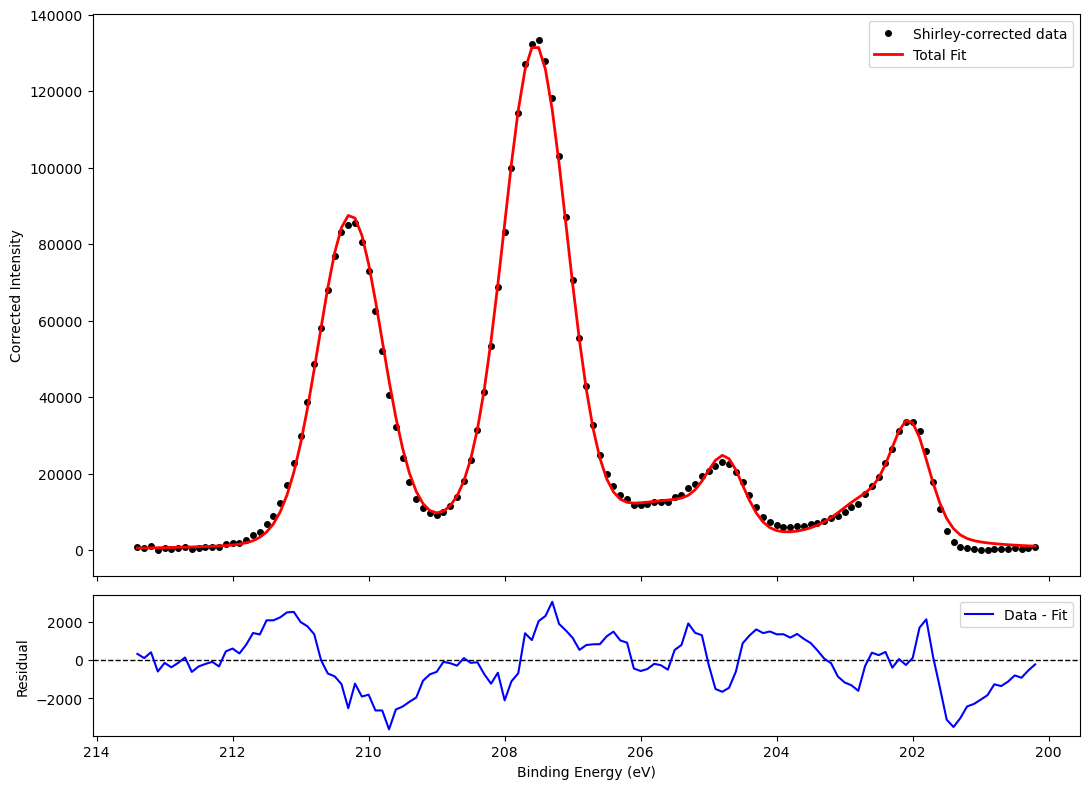

In [560]:
residuals = y - t_fit

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(11,8),
    sharex=True,
    gridspec_kw={"height_ratios":[4,1]}
)

# Main fit

ax1.plot(x, y, "ko", markersize=4, label="Shirley-corrected data")
ax1.plot(x, t_fit, "r-", linewidth=2, label="Total Fit")
ax1.set_ylabel("Corrected Intensity")
ax1.legend()

# Residuals: data - fit

ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.plot(x, residuals, "b-", linewidth=1.5, label="Data - Fit")
ax2.set_xlabel("Binding Energy (eV)")
ax2.set_ylabel("Residual")
ax2.legend()
ax1.invert_xaxis()

plt.tight_layout()
plt.show()

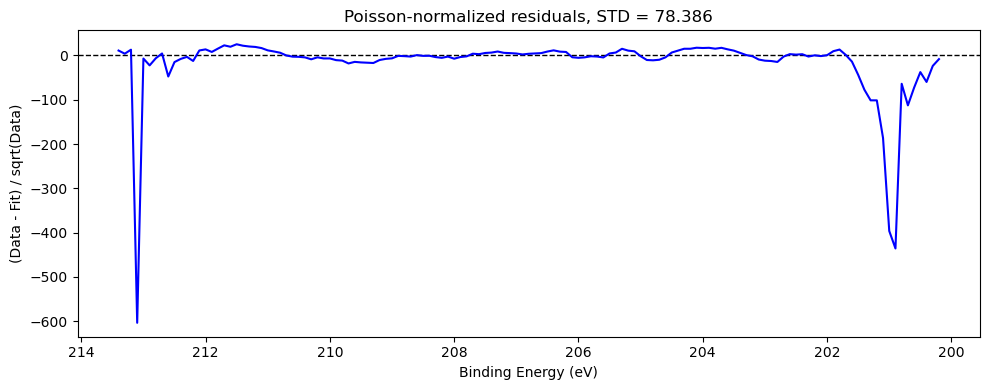

In [561]:
plt.figure(figsize=(10, 4))

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.plot(x, poisson_residuals, "b-", linewidth=1.5)

plt.gca().invert_xaxis()
plt.title(f"Poisson-normalized residuals, STD = {residual_std_poisson:.3f}")
plt.ylabel("(Data - Fit) / sqrt(Data)")
plt.xlabel("Binding Energy (eV)")
plt.tight_layout()
plt.show()

SHIFTING

In [562]:
shift = 202.200 - popt[1]

metal_shifted = popt[1] + shift
nbo_shifted   = popt[4] + shift
nbo2_shifted  = popt[7] + shift
nb2o5_shifted = popt[10] + shift

print("\nSHIFTED BINDING ENERGIES\n")

print(f"Nb metal 3d5/2: {metal_shifted:.3f} eV, FWHM = {popt[2]:.3f}")
print(f"NbO      3d5/2: {nbo_shifted:.3f} eV, FWHM = {oxide_fwhm:.3f}")
print(f"NbO2     3d5/2: {nbo2_shifted:.3f} eV, FWHM = {oxide_fwhm:.3f}")
print(f"Nb2O5    3d5/2: {nb2o5_shifted:.3f} eV, FWHM = {oxide_fwhm:.3f}")

print(f"\nApplied energy shift = {shift:+.3f} eV")


SHIFTED BINDING ENERGIES

Nb metal 3d5/2: 202.200 eV, FWHM = 0.691
NbO      3d5/2: 202.919 eV, FWHM = 1.120
NbO2     3d5/2: 206.170 eV, FWHM = 1.120
Nb2O5    3d5/2: 207.705 eV, FWHM = 1.120

Applied energy shift = +0.155 eV


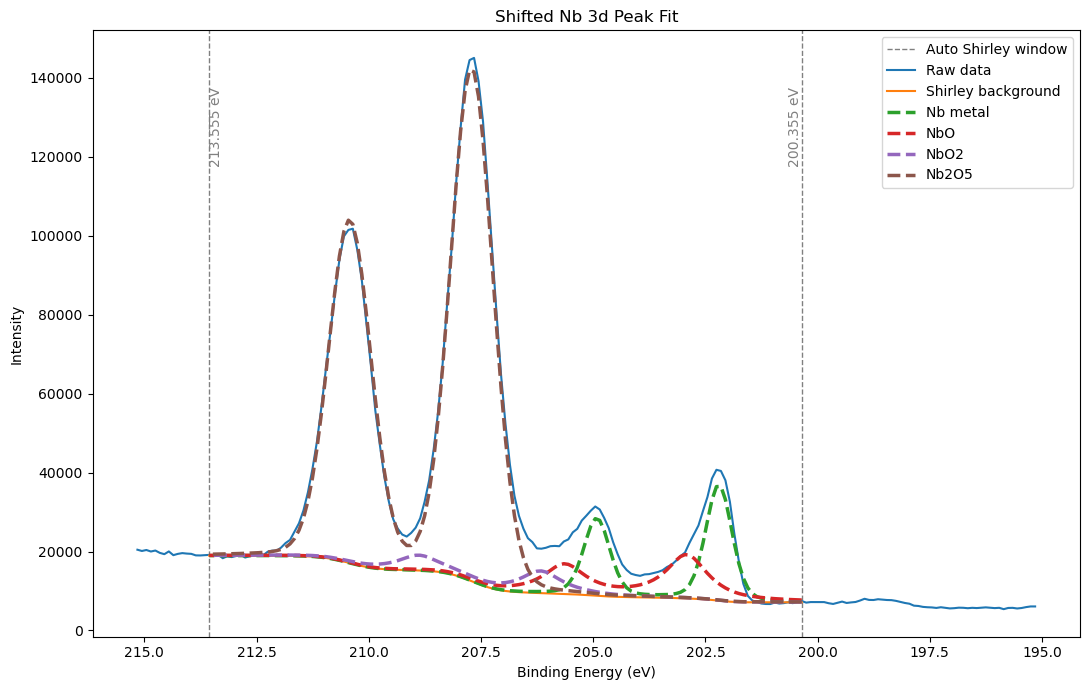

In [563]:
valid = np.isfinite(shirley)
order_bg = np.argsort(x_original[valid])

shirley_fit = np.interp(
    x,
    x_original[valid][order_bg],
    shirley[valid][order_bg]
)

plt.figure(figsize=(11, 7))

plt.axvline(SHIRLEY_MIN_BE + shift, color="gray", linestyle="--", linewidth=1, label="Auto Shirley window")
plt.axvline(SHIRLEY_MAX_BE + shift, color="gray", linestyle="--", linewidth=1)
plt.plot(x_original + shift, y_original, label="Raw data", zorder=2)
plt.plot(x_original + shift, shirley, label="Shirley background", zorder=3)

nb_m_fit_shifted = nb_m + shirley_fit
nbo_fit_shifted = nbo + shirley_fit
nbo2_fit_shifted = nbo2 + shirley_fit
nb2o5_fit_shifted = nb2o5 + shirley_fit

plt.plot(x + shift, nb_m_fit_shifted, "--", linewidth=2.5, label="Nb metal", zorder=4)
plt.plot(x + shift, nbo_fit_shifted, "--", linewidth=2.5, label="NbO", zorder=6)
plt.plot(x + shift, nbo2_fit_shifted, "--", linewidth=2.5, label="NbO2", zorder=6)
plt.plot(x + shift, nb2o5_fit_shifted, "--", linewidth=2.5, label="Nb2O5", zorder=6)

y_top = np.max(y_original +shift)

plt.text(SHIRLEY_MIN_BE + shift, y_top * 0.95, f"{SHIRLEY_MIN_BE + shift:.3f} eV",
         rotation=90, va="top", ha="right", fontsize=10, color="gray")

plt.text(SHIRLEY_MAX_BE + shift, y_top * 0.95, f"{SHIRLEY_MAX_BE + shift:.3f} eV",
         rotation=90, va="top", ha="left", fontsize=10, color="gray")

plt.xlabel("Binding Energy (eV)")
plt.ylabel("Intensity")
plt.title("Shifted Nb 3d Peak Fit")
plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()